# MVP — Sanity-check con datos SINTÉTICOS (validación de pipeline)

**TFM Grupo 1 — OBS Business School**

> **Este notebook NO usa datos reales de quejas.** `location`/`kpis_diario` son reales (copiados de `db_files/*-v1`, sin modificar), pero `claims.csv` es 100% fabricado: se inyectó a propósito una relación conocida (sitios con `avg_AVA_4G_7d < 0.98` tienen mucha más probabilidad de "queja" sintética — ver `scripts/generate_synthetic_claims.py`).
>
> **Objetivo:** confirmar que el pipeline (modelo, SHAP, ranking) recupera correctamente una señal fuerte cuando existe. Si acá el AUC-PR sale alto y SHAP identifica `avg_AVA_4G_7d` como driver dominante, confirma que el resultado débil sobre datos reales (`mvp_diagnostico_red-local.ipynb`) es una limitación genuina del dataset del cliente, no un error de metodología.

**Ejecutar:** Kernel → Restart → Run All (debe completar sin error)


In [1]:
# Colab no trae optuna/shap/xgboost preinstalados -- instalar solo si hace falta.
try:
    import google.colab  # noqa: F401
    %pip install -q optuna shap xgboost
except ImportError:
    pass

## §0 — Setup & configuración global

**Owner:** Dev-1  
**Input:** —  
**Output:** constantes globales, paths  
**Dependencias:** ninguna

In [2]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detecta Colab vs. entorno local — permite un solo notebook para ambos casos
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Carpeta dedicada del notebook en Drive (separada del remote DVC)
    drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/TFM-local')
else:
    # Permite importar desde src/ independientemente del CWD
    ROOT_DIR = Path().resolve().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# — Reproducibilidad —
RANDOM_STATE      = 42

# — Parámetros de modelado —
ROLLING_WINDOW    = 7            # días
WEEK_ANCHOR       = "W-SUN"      # fin de semana = domingo
TEST_CUTOFF_DATE  = "2026-02-01" # split temporal train/test

# — Umbrales de negocio (derivados del EDA: entregables/eda-hallazgos.md) —
AVA_THRESHOLD     = 0.98         # tasa queja 3-4x por debajo
DC_THRESHOLD      = 0.02         # tasa queja 2x por encima
THP_THRESHOLD_MBP = 15.0         # Mbps, tasa queja 2-3x por debajo

# — Columnas clave —
SITE_ID_COL  = "site_id"
WEEK_COL     = "semana"
TARGET_COL   = "es_reclamo_semanal"

# — Paths — (sintético: carpeta separada, no toca output/ real)
OUTPUT_DIR  = ROOT_DIR / "output_sint"
FIGURES_DIR = OUTPUT_DIR / "figures"
DATA_WEEKLY = OUTPUT_DIR / "modeling_dataset_weekly.parquet"
RANKING_PATH = OUTPUT_DIR / "ranking_sitios.parquet"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR   : {ROOT_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE} | TEST_CUTOFF = {TEST_CUTOFF_DATE}")

ROOT_DIR   : /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1
OUTPUT_DIR : /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output_sint
RANDOM_STATE = 42 | TEST_CUTOFF = 2026-02-01


## §1 — Carga y validación de datos

**Owner:** Dev-1  
**Input:** archivos en `db_files/`  
**Output:** `df_claims`, `df_location`, `df_kpis`  
**Dependencias:** §0

In [3]:
# Si el Parquet semanal ya existe (workflow Colab compartido), no hace falta
# el repo completo ni db_files/ crudo — Dev-2/Dev-3 solo consumen df_weekly (§2).
if DATA_WEEKLY.exists():
    df_claims = df_location = df_kpis = None
    print("Parquet semanal ya disponible — se omite carga de datos crudos (§1).")
else:
    from src.build_modeling_dataset import load_from_files, normalize, validate_integrity

    df_claims, df_location, df_kpis = load_from_files(ROOT_DIR / "db_files_sint")
    df_claims, df_location, df_kpis = normalize(df_claims, df_location, df_kpis)
    validate_integrity(df_claims, df_location, df_kpis)

    print(f"claims   : {df_claims.shape}")
    print(f"location : {df_location.shape}")
    print(f"kpis     : {df_kpis.shape}")

Parquet semanal ya disponible — se omite carga de datos crudos (§1).


## §2 — Dataset sitio × semana

**Owner:** Dev-1  
**Input:** `df_claims`, `df_location`, `df_kpis`  
**Output:** `df_weekly` → `output/modeling_dataset_weekly.parquet`  
**Dependencias:** §1

Punto de handoff crítico (H1): Dev-2 y Dev-3 leen desde el Parquet.

In [4]:
# df_weekly se construye con build_weekly() en src/build_modeling_dataset.py
# (agrega claims a sitio×semana, KPIs rolling leakage-safe, normaliza por USERS_4G).
# El notebook no reimplementa esa lógica — solo carga el Parquet ya generado.
if DATA_WEEKLY.exists():
    df_weekly = pd.read_parquet(DATA_WEEKLY)
    print(f"df_weekly cargado desde Parquet: {df_weekly.shape}")
    print(f"Positivos: {df_weekly[TARGET_COL].sum()} / {len(df_weekly)} = {df_weekly[TARGET_COL].mean():.2%}")
else:
    raise FileNotFoundError(
        f"Parquet no encontrado: {DATA_WEEKLY}. "
        "Ejecutar `python src/build_modeling_dataset.py --grain weekly --source files` primero."
    )

df_weekly cargado desde Parquet: (68971, 12)
Positivos: 731 / 68971 = 1.06%


## §3 — EDA diagnóstico

**Owner:** Dev-2  
**Input:** `df_weekly` (vía Parquet si §2 no está corrido)  
**Output:** figuras en `output/figures/`, hallazgos documentados  
**Dependencias:** §2 (Parquet H1)

Distribución del target:
es_reclamo_semanal
0    0.989401
1    0.010599
Name: proporción, dtype: float64


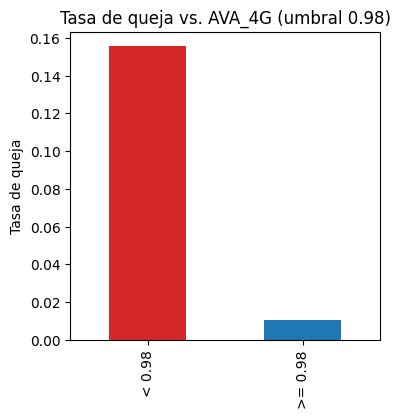

< 0.98     0.155488
>= 0.98    0.010399
Name: es_reclamo_semanal, dtype: float64


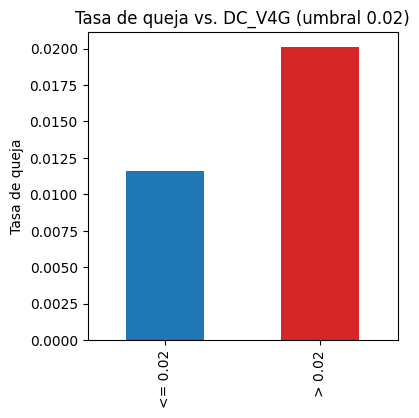

<= 0.02    0.011616
> 0.02     0.020128
Name: es_reclamo_semanal, dtype: float64


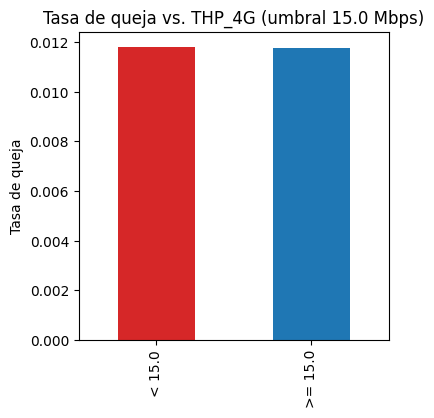

< 15.0     0.011817
>= 15.0    0.011749
Name: es_reclamo_semanal, dtype: float64


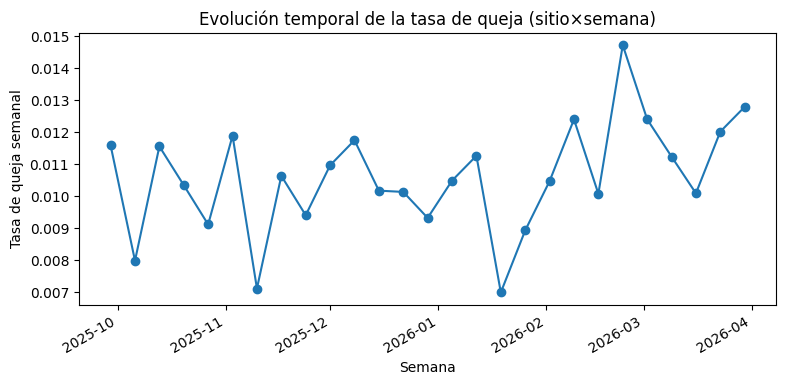

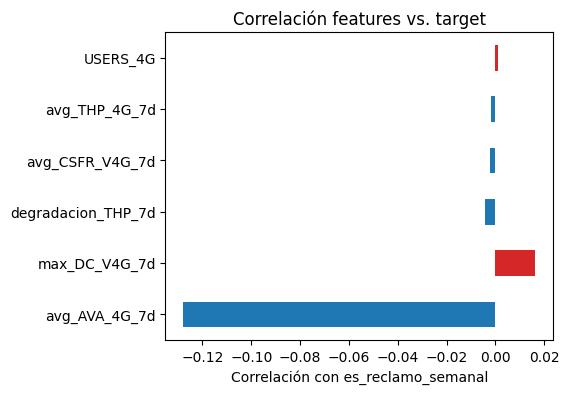

avg_AVA_4G_7d        -0.127916
max_DC_V4G_7d         0.016385
degradacion_THP_7d   -0.004152
avg_CSFR_V4G_7d      -0.002139
avg_THP_4G_7d        -0.001593
USERS_4G              0.001275
Name: es_reclamo_semanal, dtype: float64


In [5]:
# Asegurar que df_weekly está disponible (puede cargar sin correr §2)
if "df_weekly" not in dir():
    df_weekly = pd.read_parquet(DATA_WEEKLY)

# 1. Distribución del target
print("Distribución del target:")
print(df_weekly[TARGET_COL].value_counts(normalize=True).rename("proporción"))


def _tasa_por_bucket(df: pd.DataFrame, col: str, umbral: float, mayor_es_malo: bool) -> pd.Series:
    """Tasa de queja por encima/debajo del umbral de negocio de la columna."""
    d = df.dropna(subset=[col])
    if mayor_es_malo:
        bucket = np.where(d[col] > umbral, f"> {umbral}", f"<= {umbral}")
    else:
        bucket = np.where(d[col] < umbral, f"< {umbral}", f">= {umbral}")
    return d.groupby(bucket)[TARGET_COL].mean()


# 2. Tasa queja vs. bucket AVA
tasa_ava = _tasa_por_bucket(df_weekly, "avg_AVA_4G_7d", AVA_THRESHOLD, mayor_es_malo=False)
fig_ava_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_ava.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. AVA_4G (umbral {AVA_THRESHOLD})")
fig_ava_bucket.savefig(FIGURES_DIR / "eda_ava_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_ava)

# 3. Tasa queja vs. bucket DC
tasa_dc = _tasa_por_bucket(df_weekly, "max_DC_V4G_7d", DC_THRESHOLD, mayor_es_malo=True)
fig_dc_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_dc.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. DC_V4G (umbral {DC_THRESHOLD})")
fig_dc_bucket.savefig(FIGURES_DIR / "eda_dc_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_dc)

# 4. Tasa queja vs. bucket THP
tasa_thp = _tasa_por_bucket(df_weekly, "avg_THP_4G_7d", THP_THRESHOLD_MBP, mayor_es_malo=False)
fig_thp_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_thp.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. THP_4G (umbral {THP_THRESHOLD_MBP} Mbps)")
fig_thp_bucket.savefig(FIGURES_DIR / "eda_thp_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_thp)

# 5. Evolución temporal de quejas
temporal = df_weekly.groupby(WEEK_COL)[TARGET_COL].agg(n_reclamos="sum", tasa="mean").reset_index()
temporal[WEEK_COL] = temporal[WEEK_COL].dt.start_time
fig_temporal, ax = plt.subplots(figsize=(9, 4))
ax.plot(temporal[WEEK_COL], temporal["tasa"], marker="o")
ax.set_ylabel("Tasa de queja semanal")
ax.set_xlabel("Semana")
ax.set_title("Evolución temporal de la tasa de queja (sitio×semana)")
fig_temporal.autofmt_xdate()
fig_temporal.savefig(FIGURES_DIR / "eda_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Correlación features vs. TARGET_COL
# Columnas de KPI disponibles en df_weekly ya en §3 (FEATURE_COLS se define recién en §4)
_KPI_COLS = ["avg_AVA_4G_7d", "max_DC_V4G_7d", "avg_THP_4G_7d", "degradacion_THP_7d", "avg_CSFR_V4G_7d", "USERS_4G"]
corr = df_weekly[_KPI_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
fig_correlation, ax = plt.subplots(figsize=(5, 4))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#d62728", "#1f77b4"))
ax.set_xlabel(f"Correlación con {TARGET_COL}")
ax.set_title("Correlación features vs. target")
fig_correlation.savefig(FIGURES_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(corr)

> **Hallazgo [sintético — completar tras correr]:** verificar que la tasa de queja por bucket AVA muestre el efecto inyectado (~15% vs ~1%, ver `scripts/generate_synthetic_claims.py`). Este notebook usa datos fabricados — no reemplaza el hallazgo real de `mvp_diagnostico_red-local.ipynb`.

## §4 — Feature engineering y split temporal

**Owner:** Dev-1  
**Input:** `df_weekly`  
**Output:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`  
**Dependencias:** §2

Punto de handoff H2: Dev-2 y Dev-3 consumen estas variables directamente.

In [6]:
FEATURE_COLS = [
    "avg_AVA_4G_7d",
    "max_DC_V4G_7d",
    "avg_THP_4G_7d",
    "degradacion_THP_7d",
    "avg_CSFR_V4G_7d",
    "USERS_4G",
    # "reclamos_por_usuario" -- NO USAR: es n_reclamos_semana / USERS_4G, calculado con
    # el conteo de reclamos de la MISMA semana que define TARGET_COL -> data leakage directo.
    # Categoricals one-hot-encoded
    # "tipo_negocio_B2C", "tipo_negocio_B2B", "tipo_negocio_PREPAGO",
]

# Filas sin ventana rolling previa (primera semana con datos por sitio) quedan con nulos
# en FEATURE_COLS -- no es missing real, es artefacto de .shift(1).rolling(). Se descartan.
# degradacion_THP_7d puede dar inf si avg_THP_4G_7d es 0 (denominador) -- dropna() no
# atrapa inf, hay que convertirlo a NaN primero para que se descarte igual que los demás.
df_model = df_weekly.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURE_COLS).copy()
print(f"Filas descartadas (sin ventana rolling): {len(df_weekly) - len(df_model)} "
      f"({1 - len(df_model) / len(df_weekly):.1%})")

# Split temporal -- nunca aleatorio en series de tiempo
mask_train = df_model[WEEK_COL] < TEST_CUTOFF_DATE
df_train   = df_model[mask_train].copy()
df_test    = df_model[~mask_train].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

print(f"Train: {X_train.shape} | positivos={y_train.sum()} ({y_train.mean():.2%})")
print(f"Test : {X_test.shape}  | positivos={y_test.sum()} ({y_test.mean():.2%})")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Filas descartadas (sin ventana rolling): 8353 (12.1%)
Train: (37425, 6) | positivos=429 (1.15%)
Test : (23193, 6)  | positivos=297 (1.28%)
Features (6): ['avg_AVA_4G_7d', 'max_DC_V4G_7d', 'avg_THP_4G_7d', 'degradacion_THP_7d', 'avg_CSFR_V4G_7d', 'USERS_4G']


## §5 — Modelos (baseline / LR / XGBoost)

**Owner:** Dev-2  
**Input:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`, `RANDOM_STATE`  
**Output:** `model_rules`, `model_lr`, `model_xgb`, `y_pred_*`, `y_prob_*`  
**Dependencias:** §4 (handoff H2)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
import optuna
from sklearn.impute import SimpleImputer # Import SimpleImputer

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Baseline de reglas ---
class RulesBaseline:
    """Flag si AVA < umbral OR DC > umbral OR THP < umbral (umbrales de negocio, EDA)."""

    def _rule_count(self, X: pd.DataFrame) -> pd.Series:
        return (
            (X["avg_AVA_4G_7d"] < AVA_THRESHOLD).astype(int)
            + (X["max_DC_V4G_7d"] > DC_THRESHOLD).astype(int)
            + (X["avg_THP_4G_7d"] < THP_THRESHOLD_MBP).astype(int)
        )

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self._rule_count(X) > 0).astype(int).to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        # Score continuo: fracción de las 3 reglas de negocio que dispara.
        prob_pos = (self._rule_count(X) / 3).to_numpy()
        return np.column_stack([1 - prob_pos, prob_pos])


model_rules = RulesBaseline()
y_pred_rules = model_rules.predict(X_test)
y_prob_rules = model_rules.predict_proba(X_test)[:, 1]

# --- Logistic Regression ---
# StandardScaler necesario: features en escalas muy distintas (AVA 0-1, USERS_4G hasta ~500+).
# Se agrega SimpleImputer para manejar NaNs antes del StandardScaler
model_lr = make_pipeline(
    SimpleImputer(strategy='mean'), # Handle missing values
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs"),
)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# --- XGBoost + Optuna ---
# scale_pos_weight = n_neg/n_pos: equivalente a class_weight='balanced' en sklearn
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# CV interno para tuning: StratifiedKFold, no TimeSeriesSplit. Con ~0.7% de positivos
# concentrados en pocas semanas del train, TimeSeriesSplit produce folds sin ningún
# positivo (average_precision indefinido). El split train/test SÍ es estrictamente
# temporal (TEST_CUTOFF_DATE) -- ahí es donde importa evitar leakage hacia el futuro;
# el CV interno solo reordena semanas ya vistas en train para elegir hiperparámetros.
def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="aucpr",
    )
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, prob))
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = dict(study.best_params)
best_params.update(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="aucpr")
model_xgb = XGBClassifier(**best_params)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight = {scale_pos_weight:.1f}")
print(f"Optuna best AUC-PR (CV interno): {study.best_value:.4f}")
print(f"Best params XGBoost: {best_params}")

/Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scale_pos_weight = 86.2
Optuna best AUC-PR (CV interno): 0.0543
Best params XGBoost: {'n_estimators': 127, 'max_depth': 2, 'learning_rate': 0.014804043102195208, 'subsample': 0.7156334435826419, 'colsample_bytree': 0.6979002135771539, 'min_child_weight': 9, 'scale_pos_weight': np.float64(86.23776223776224), 'random_state': 42, 'eval_metric': 'aucpr'}


## §6 — Evaluación comparativa

**Owner:** Dev-2  
**Input:** `y_test`, `y_pred_*`, `y_prob_*`  
**Output:** `df_metrics`, `fig_aucpr`  
**Dependencias:** §5

 modelo   AUC-PR   Recall  Precision       F1  n_alertas
 Reglas 0.019391 0.387205   0.020264 0.038513       5675
     LR 0.067038 0.242424   0.029292 0.052269       2458
XGBoost 0.057648 0.276094   0.023879 0.043956       3434


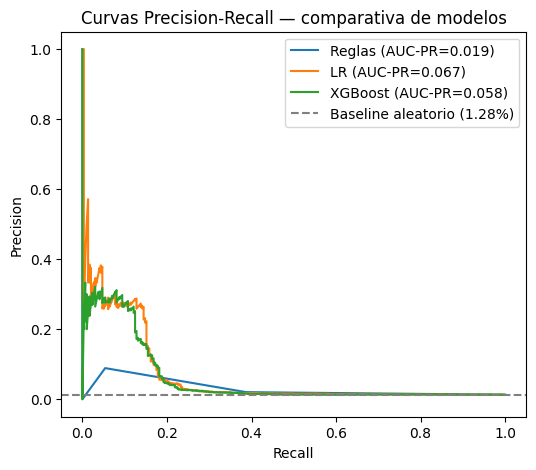

In [8]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, f1_score

_preds = {
    "Reglas":  (y_pred_rules, y_prob_rules),
    "LR":      (y_pred_lr, y_prob_lr),
    "XGBoost": (y_pred_xgb, y_prob_xgb),
}

df_metrics = pd.DataFrame([
    {
        "modelo": name,
        "AUC-PR": average_precision_score(y_test, yprob),
        "Recall": recall_score(y_test, ypred),
        "Precision": precision_score(y_test, ypred, zero_division=0),
        "F1": f1_score(y_test, ypred, zero_division=0),
        "n_alertas": int(ypred.sum()),
    }
    for name, (ypred, yprob) in _preds.items()
])
print(df_metrics.to_string(index=False))

# fig_aucpr: curvas PR superpuestas
fig_aucpr, ax = plt.subplots(figsize=(6, 5))
for name, (_, yprob) in _preds.items():
    precision, recall, _ = precision_recall_curve(y_test, yprob)
    ax.plot(recall, precision, label=f"{name} (AUC-PR={average_precision_score(y_test, yprob):.3f})")
ax.axhline(y_test.mean(), color="grey", linestyle="--", label=f"Baseline aleatorio ({y_test.mean():.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall — comparativa de modelos")
ax.legend()
fig_aucpr.savefig(FIGURES_DIR / "aucpr_models.png", dpi=150, bbox_inches="tight")
plt.show()

## §7 — Explicabilidad SHAP

**Owner:** Dev-3  
**Input:** `model_xgb`, `X_train`, `X_test`, `FEATURE_COLS`  
**Output:** `explainer`, `shap_values`, `fig_shap_bar`, `fig_shap_scatter`  
**Dependencias:** §5 (handoff H3)

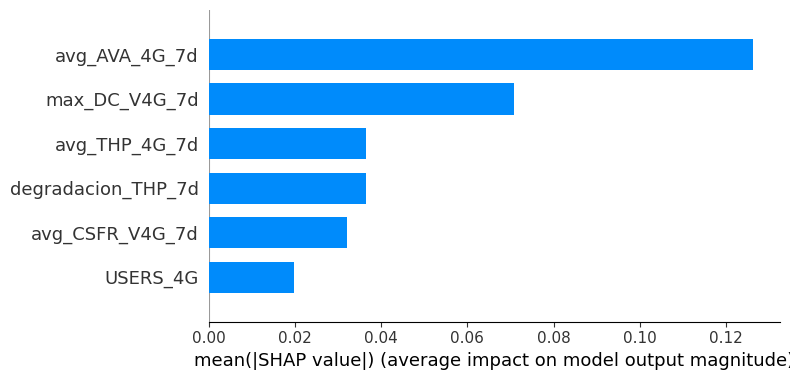

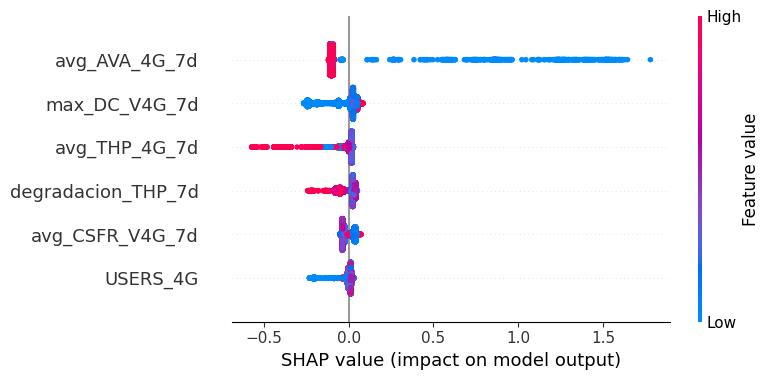

Ejemplo — driver por sitio: {'avg_AVA_4G_7d': np.float32(-0.10239902), 'max_DC_V4G_7d': np.float32(0.025119457), 'avg_THP_4G_7d': np.float32(0.018258715), 'degradacion_THP_7d': np.float32(0.029627312), 'avg_CSFR_V4G_7d': np.float32(0.034273893), 'USERS_4G': np.float32(0.0057962653)}
Acción recomendada: Mantenimiento programado


In [9]:
import shap

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)   # shape: (n_rows, n_features)

# fig_shap_bar: importancia global
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
fig_shap_bar = plt.gcf()
fig_shap_bar.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# fig_shap_scatter: beeswarm con dirección del efecto
shap.summary_plot(shap_values, X_test, show=False)
fig_shap_scatter = plt.gcf()
fig_shap_scatter.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Mapeo driver dominante -> acción recomendada.
_ACCION_MAP = {
    "avg_THP_4G_7d":       "Inversión tecnológica",   # capacidad/throughput crónico
    "degradacion_THP_7d":  "Inversión tecnológica",
    "avg_AVA_4G_7d":       "Mantenimiento programado",  # disponibilidad puntual
    "max_DC_V4G_7d":       "Mantenimiento programado",  # caída de llamada puntual
    "avg_CSFR_V4G_7d":     "Mantenimiento programado",  # fallo de establecimiento puntual
    "USERS_4G":            "Monitoreo",  # tráfico solo, no es señal de degradación
}
# Umbral relativo a la magnitud típica de SHAP en este modelo (10% de la media |SHAP|)
# en vez de una constante fija -- se adapta si cambia la escala de las features.
SHAP_SIGNAL_THRESHOLD = 0.1 * np.abs(shap_values).mean()


def clasifica_accion(shap_row: dict) -> str:
    """Retorna acción recomendada basada en el driver SHAP dominante del sitio.

    - driver = capacidad/throughput crónico -> "Inversión tecnológica"
    - driver = disponibilidad/confiabilidad puntual (AVA/DC/CSFR) -> "Mantenimiento programado"
    - sin señal clara (|SHAP| por debajo del umbral en todas las features) -> "Monitoreo"
    """
    if not shap_row:
        return "Monitoreo"
    driver, value = max(shap_row.items(), key=lambda kv: abs(kv[1]))
    if abs(value) < SHAP_SIGNAL_THRESHOLD:
        return "Monitoreo"
    return _ACCION_MAP.get(driver, "Monitoreo")


# Ejemplo: primer sitio del test set
_ejemplo = dict(zip(FEATURE_COLS, shap_values[0]))
print(f"Ejemplo — driver por sitio: {_ejemplo}")
print(f"Acción recomendada: {clasifica_accion(_ejemplo)}")

> **Hallazgo [sintético — completar tras correr]:** el driver SHAP dominante debería ser `avg_AVA_4G_7d` (es la señal inyectada). Si sale así, confirma que el pipeline recupera correctamente una relación fuerte cuando existe.

## §8 — Segmentación de sitios

**Owner:** Dev-3  
**Input:** `df_weekly` (features agregadas por sitio)  
**Output:** `df_sites_clustered` (con columnas `cluster` y `perfil`)  
**Dependencias:** §2 (Parquet)

k=3: silhouette=0.2958


k=4: silhouette=0.3018
k=5: silhouette=0.3109

k elegido: 5 (silhouette=0.3109)
perfil
Sin señal relevante             1164
Alta carga + bajo throughput    1151
Disponibilidad puntual baja       22
Name: count, dtype: int64


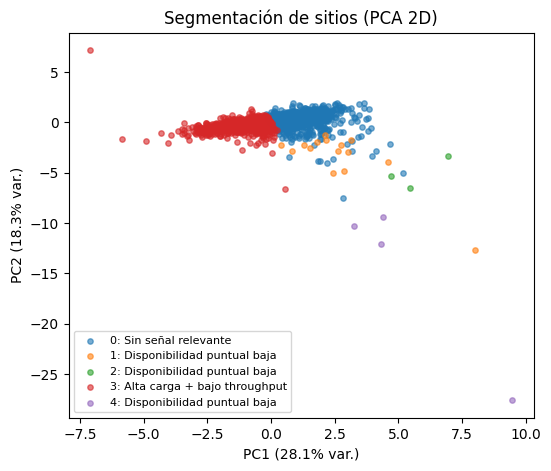

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Agregar df_weekly a nivel site_id (promedio del período completo)
df_sites = (
    df_weekly.dropna(subset=FEATURE_COLS)
    .groupby(SITE_ID_COL)[FEATURE_COLS]
    .mean()
    .reset_index()
)

# 2. Escalar antes de clustering
scaler = StandardScaler()
X_sites_scaled = scaler.fit_transform(df_sites[FEATURE_COLS])

# 3. KMeans k=3..5, elegir k con mejor silhouette score
_best = {"k": None, "score": -1, "labels": None}
for k in range(3, 6):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_sites_scaled)
    score = silhouette_score(X_sites_scaled, labels)
    print(f"k={k}: silhouette={score:.4f}")
    if score > _best["score"]:
        _best = {"k": k, "score": score, "labels": labels}

df_sites["cluster"] = _best["labels"]
print(f"\nk elegido: {_best['k']} (silhouette={_best['score']:.4f})")

# 4. Etiquetar clusters con perfil descriptivo, según medias del cluster vs. umbrales de negocio.
_CSFR_REFERENCE = 0.05  # sin umbral oficial de negocio para CSFR (solo AVA/DC/THP en §0); referencia propia.
_users_median = df_sites["USERS_4G"].median()
_cluster_means = df_sites.groupby("cluster")[FEATURE_COLS].mean()


def _perfil_cluster(mean_row: pd.Series) -> str:
    thp_bad  = mean_row["avg_THP_4G_7d"] < THP_THRESHOLD_MBP
    ava_bad  = mean_row["avg_AVA_4G_7d"] < AVA_THRESHOLD
    dc_bad   = mean_row["max_DC_V4G_7d"] > DC_THRESHOLD
    csfr_bad = mean_row["avg_CSFR_V4G_7d"] > _CSFR_REFERENCE
    high_load = mean_row["USERS_4G"] > _users_median
    if thp_bad and high_load:
        return "Alta carga + bajo throughput"
    if thp_bad:
        return "Degradación crónica de capacidad"
    if ava_bad or dc_bad or csfr_bad:
        return "Disponibilidad puntual baja"
    return "Sin señal relevante"


_perfil_por_cluster = {c: _perfil_cluster(row) for c, row in _cluster_means.iterrows()}
df_sites["perfil"] = df_sites["cluster"].map(_perfil_por_cluster)
df_sites_clustered = df_sites

print(df_sites_clustered["perfil"].value_counts())

# 5. fig_cluster_scatter (PCA 2D)
_pca = PCA(n_components=2, random_state=RANDOM_STATE)
_coords = _pca.fit_transform(X_sites_scaled)

fig_cluster_scatter, ax = plt.subplots(figsize=(6, 5))
for c in sorted(df_sites_clustered["cluster"].unique()):
    mask = df_sites_clustered["cluster"] == c
    ax.scatter(_coords[mask, 0], _coords[mask, 1], label=f"{c}: {_perfil_por_cluster[c]}", alpha=0.6, s=15)
ax.set_xlabel(f"PC1 ({_pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({_pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("Segmentación de sitios (PCA 2D)")
ax.legend(fontsize=8)
fig_cluster_scatter.savefig(FIGURES_DIR / "cluster_sitios.png", dpi=150, bbox_inches="tight")
plt.show()

## §9 — Ranking accionable (output final)

**Owner:** Dev-3  
**Input:** `df_weekly` (test), `y_prob_xgb`, `shap_values`, `df_sites_clustered`  
**Output:** `df_ranking` → `output/ranking_sitios.parquet`  
**Dependencias:** §5, §7, §8

In [11]:
# 1 fila por site_id: se usa la semana más reciente del período test como "estado actual".
df_test_scored = df_test.reset_index(drop=True).copy()
df_test_scored["score_riesgo"] = y_prob_xgb

_latest_idx = df_test_scored.groupby(SITE_ID_COL)[WEEK_COL].idxmax()
df_ranking = df_test_scored.loc[_latest_idx].reset_index(drop=True)

# shap_values está alineado a X_test/df_test_scored por posición -- se indexa igual.
_shap_by_pos = {i: dict(zip(FEATURE_COLS, shap_values[i])) for i in _latest_idx.to_numpy()}


def _top2_drivers(pos: int) -> str:
    row = _shap_by_pos[pos]
    top = sorted(row.items(), key=lambda kv: abs(kv[1]), reverse=True)[:2]
    return ", ".join(k for k, _ in top)


def _umbral_incumplido(row: pd.Series) -> str:
    viol = []
    if row["avg_AVA_4G_7d"] < AVA_THRESHOLD:
        viol.append("AVA_4G")
    if row["max_DC_V4G_7d"] > DC_THRESHOLD:
        viol.append("DC_V4G")
    if row["avg_THP_4G_7d"] < THP_THRESHOLD_MBP:
        viol.append("THP_4G")
    return ", ".join(viol) if viol else "ninguno"


df_ranking["kpis_driver"] = [_top2_drivers(i) for i in _latest_idx.to_numpy()]
df_ranking["umbral_incumplido"] = df_ranking.apply(_umbral_incumplido, axis=1)
df_ranking["accion_recomendada"] = [clasifica_accion(_shap_by_pos[i]) for i in _latest_idx.to_numpy()]
df_ranking["prioridad_sitio"] = 0  # actualizar cuando el cliente provea el campo (1-6)

df_ranking = df_ranking.merge(df_sites_clustered[[SITE_ID_COL, "cluster"]], on=SITE_ID_COL, how="left")

_semanas_en_riesgo = df_weekly.groupby(SITE_ID_COL)[TARGET_COL].sum().rename("semanas_en_riesgo")
df_ranking = df_ranking.merge(_semanas_en_riesgo, on=SITE_ID_COL, how="left")

df_ranking = df_ranking[[
    SITE_ID_COL, "score_riesgo", "prioridad_sitio", "kpis_driver",
    "umbral_incumplido", "accion_recomendada", "cluster", "semanas_en_riesgo",
]].sort_values("score_riesgo", ascending=False)

df_ranking.to_parquet(RANKING_PATH, index=False)

print(f"Ranking guardado: {RANKING_PATH}")
print(f"Top 10 sitios de mayor riesgo:")
display(df_ranking.head(10))

Ranking guardado: /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output_sint/ranking_sitios.parquet
Top 10 sitios de mayor riesgo:


,site_id,score_riesgo,prioridad_sitio,kpis_driver,umbral_incumplido,accion_recomendada,cluster,semanas_en_riesgo
1502,2545,0.835730,0,"avg_AVA_4G_7d, max_DC_V4G_7d","AVA_4G, DC_V4G",Mantenimiento programado,1,2
1604,317,0.835627,0,"avg_AVA_4G_7d, max_DC_V4G_7d","AVA_4G, THP_4G",Mantenimiento programado,4,0
1916,613,0.830019,0,"avg_AVA_4G_7d, USERS_4G",AVA_4G,Mantenimiento programado,4,10
825,1842,0.828564,0,"avg_AVA_4G_7d, avg_CSFR_V4G_7d",AVA_4G,Mantenimiento programado,0,2
2123,807,0.822766,0,"avg_AVA_4G_7d, avg_CSFR_V4G_7d","AVA_4G, THP_4G",Mantenimiento programado,3,5
360,1360,0.821846,0,"avg_AVA_4G_7d, max_DC_V4G_7d",AVA_4G,Mantenimiento programado,0,1
1416,2441,0.821064,0,"avg_AVA_4G_7d, max_DC_V4G_7d","AVA_4G, THP_4G",Mantenimiento programado,3,3
959,1969,0.818100,0,"avg_AVA_4G_7d, max_DC_V4G_7d",AVA_4G,Mantenimiento programado,0,1
837,1854,0.811731,0,"avg_AVA_4G_7d, avg_CSFR_V4G_7d",AVA_4G,Mantenimiento programado,0,2
1233,2226,0.810165,0,"avg_AVA_4G_7d, degradacion_THP_7d",AVA_4G,Mantenimiento programado,0,2


---

## Checklist de entrega

- [ ] Kernel Restart → Run All completa sin error
- [ ] `output/modeling_dataset_weekly.parquet` generado
- [ ] `output/ranking_sitios.parquet` generado con 8 columnas del schema
- [ ] `df_metrics` impreso con AUC-PR para los 3 modelos
- [ ] Al menos 1 figura SHAP global en `output/figures/`
- [ ] `RANDOM_STATE = 42` en todos los modelos
- [ ] `TEST_CUTOFF_DATE` documentado con justificación
- [ ] Variables con nombres definidos en `entregables/pipeline.md`